# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting. 

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points) 
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries? 

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below: 

* Source 1: https://en.wikipedia.org/wiki/Gaussian_blur
* Source 2: https://computergraphics.stackexchange.com/questions/39/how-is-gaussian-blur-implemented
* Source 3: 
* Source 4: 
* Source 5: 

## Code (70 points) 
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient. 

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


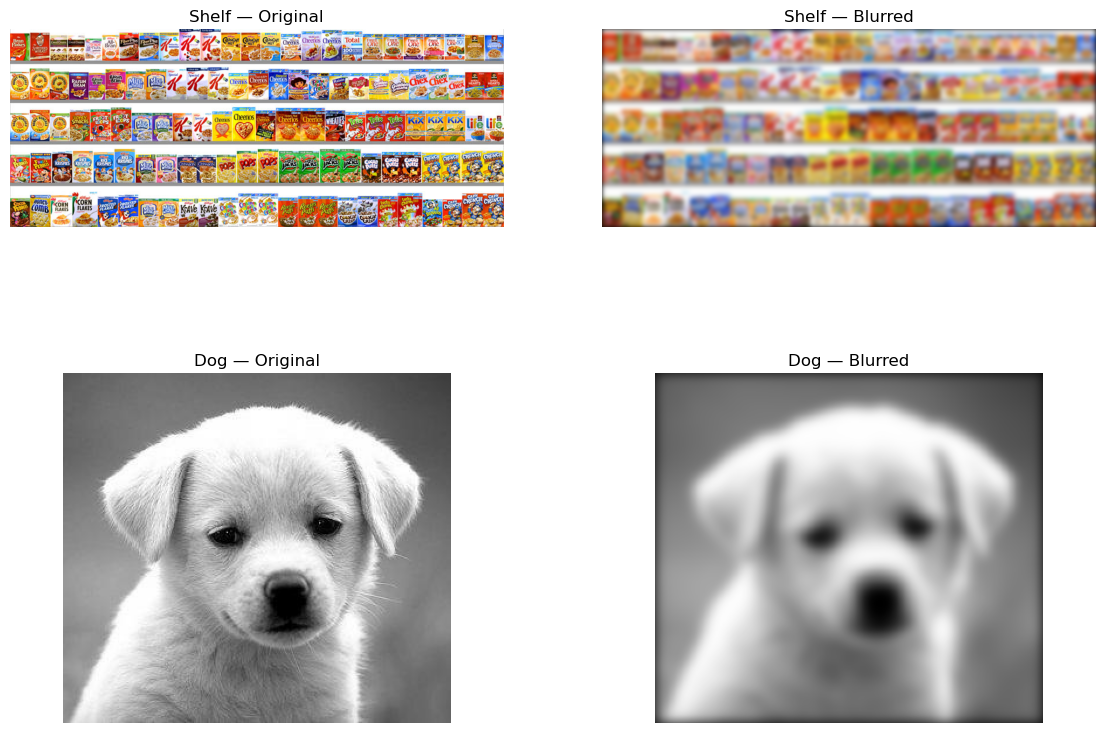

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from filters import conv_fast

BLUR_FACTOR = 5 

def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return G / G.sum()

def blur_image(img_array, blur_factor=1.0):
    sigma = blur_factor
    size = max(3, int(6 * sigma) | 1) 
    kernel = gaussian_kernel(size=size, sigma=sigma)
    if img_array.ndim == 3:
        blurred = np.stack([conv_fast(img_array[:, :, c], kernel) for c in range(img_array.shape[2])], axis=2)
    else:
        blurred = conv_fast(img_array, kernel)
    return np.clip(blurred, 0, 255).astype(np.uint8)

shelf = np.array(Image.open("shelf.jpg"))
dog   = np.array(Image.open("dog.jpg"))

shelf_blurred = blur_image(shelf, blur_factor=BLUR_FACTOR)
dog_blurred   = blur_image(dog,   blur_factor=BLUR_FACTOR)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(shelf)
plt.title('Shelf — Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(shelf_blurred)
plt.title('Shelf — Blurred')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(dog)
plt.title('Dog — Original')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(dog_blurred)
plt.title('Dog — Blurred')
plt.axis('off')

plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

I built on top of the conv_fast function from Part 1 and implemented an adjustable Gaussian blur filter. I constructed a 2D Gaussian kernel using the formulas found on Wikipedia and Stack exchange and applied this kernel to the image using conv_fast from Part 1. We center at 0 so that the blur is symmetric. If the center were off to one side, the blur would shift the image instead of just smoothing it. To achieve this, I write two functions: gaussian_kernel and blur_image. 

The first function, gaussian_kernel, builds a 2D grid of weights shaped like a bell curve.


After creating an initial blur, I wanted to enhance this but being able to tune the blur factor. I thought this would be interesting to add more dimension and make this filter more practical. Originally, the blur factor was slight and not obvious for the shelf image due to the nature of the image. 